In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
gdp_df = pd.read_csv('../data/gdp_percapita.csv')
gdp_df

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN
...,...,...,...,...
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN


# How many rows and columns are in `gdp_df`? What are the data types of each column?
8465 rows, 4 columns
Country or Area = object
Year = int64 (integer)
Value = float64 (decimal)
Value Footnotes = float64 (decimal)

In [3]:
gdp_df.shape

(8465, 4)

In [4]:
gdp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country or Area  8465 non-null   object 
 1   Year             8465 non-null   int64  
 2   Value            8465 non-null   float64
 3   Value Footnotes  0 non-null      float64
dtypes: float64(2), int64(1), object(1)
memory usage: 264.7+ KB


In [5]:
gdp_df = gdp_df.drop(columns = ['Value Footnotes'])
gdp_df.head()

,Country or Area,Year,Value
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144


In [6]:
gdp_df.columns = ['Country', 'Year', 'GDP_Per_Capita']
gdp_df.head()

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144


In [7]:
country_counts = gdp_df.Country.value_counts()
country_counts.reset_index()
df_country_counts = country_counts.reset_index()

In [8]:
gdp_df['Year'].nunique()

35

In [2]:
#solutions - go back and fix
gdp_df.Country.value_counts().reset_index()
country_count = gdp_df.Country.value_counts().reset_index()
country_count.columns = ['Country', 'Count']
(country_count.Count == 35).sum()
len(country_count) - (country_count.Count ==35).sum()
(country_count.Count == 35).sum()

NameError: name 'gdp_df' is not defined

In [9]:
full_countries = df_country_counts[df_country_counts == 35]
full_countries.count()

Country      0
count      226
dtype: int64

In [10]:
country_counts[country_counts == 35].count()

np.int64(226)

In [11]:
#7 226 countries have data for all years

In [ ]:
#solutions
years = gdp_df.Year.value_counts().reset_index()
years.columns = ['Year', 'Count']
years.sort_values('Year')

In [12]:
missing_countries = df_country_counts[df_country_counts != 35]
missing_countries.count()

Country    247
count       21
dtype: int64

In [13]:
#7 21 countries have missing data

In [14]:
country_counts[country_counts != 35]

Country
Lebanon                      34
Tuvalu                       34
Somalia, Fed. Rep.           34
Tonga                        34
Bhutan                       34
Greenland                    34
Palau                        34
Syrian Arab Republic         33
West Bank and Gaza           31
Serbia                       30
Montenegro                   28
San Marino                   27
CuraÃ§ao                     25
Afghanistan                  24
Virgin Islands (US)          21
Turks and Caicos Islands     18
Cayman Islands               18
Kosovo                       17
Faroe Islands                17
Sint Maarten (Dutch part)    16
Djibouti                     12
Name: count, dtype: int64

In [15]:
gdp_df.Year.value_counts()

Year
2015    247
2021    247
2020    247
2019    247
2018    247
2017    247
2016    247
2022    247
2014    247
2013    247
2012    246
2011    246
2010    246
2009    246
2008    245
2023    245
2007    243
2006    242
2005    241
2004    241
2003    241
2002    241
2001    240
2000    240
1997    238
1998    238
1999    238
2024    236
1996    236
1995    236
1994    235
1993    234
1992    234
1991    234
1990    233
Name: count, dtype: int64

In [16]:
#7 Observations per year goes down the later the year ie less count as we go back in time

In [ ]:
#solution
gdp_2020 = gdp_df.loc[gdp_df.Year == 2020]
gdp_2020.his('GDP_Per_Capita'); #adding ; at the end removes stuff on the top

In [ ]:
gdp_2020 = gdp_df[gdp_df['Year'] == 2020]

In [ ]:
plt.hist(gdp_2020['GDP_Per_Capita'], bins=50)

<Axes: xlabel='GDP_Per_Capita', ylabel='Density'>

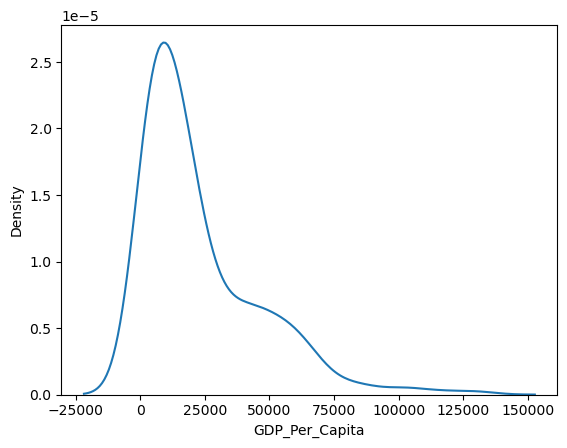

In [19]:
sns.kdeplot(gdp_2020['GDP_Per_Capita'])

In [ ]:
#solution
sns.kdeplot(data = gdp_2020, x = 'GDP_Per_Capita');

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

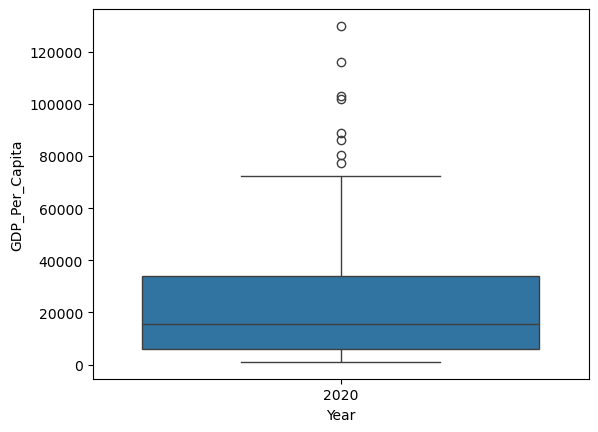

In [20]:
sns.boxplot( x=gdp_2020['Year'], y=gdp_2020['GDP_Per_Capita'] )

In [ ]:
#solution
gdp_2020.boxplot('GDP_Per_Capita');

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

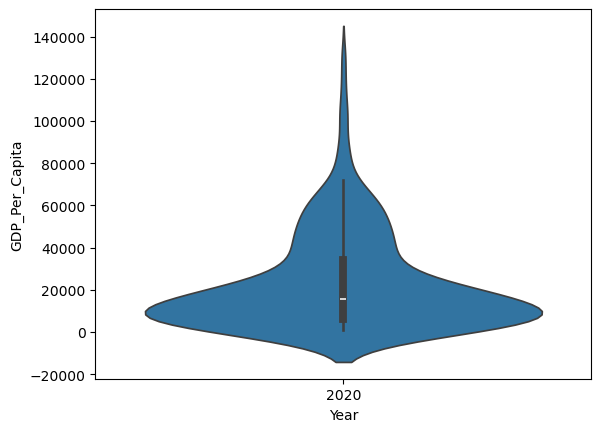

In [21]:
sns.violinplot(x=gdp_2020['Year'], y=gdp_2020['GDP_Per_Capita'])

In [ ]:
#solution
gdp_2020.violinplot(data = gdp_2020, x = 'GDP_Per_Capita');

In [22]:
round(gdp_2020['GDP_Per_Capita'].median(),2)

15399.31

In [ ]:
#solution
gdp_2020.GDP_Per_Capita.median()
gdp_2020.describe()

In [23]:
#9 Median 2020 GDP = 15,399.31

In [ ]:
#solution Q10
my_decades = [1990, 2000, 2010, 2020]
gdp_decades2 = gdp_df.loc[gdp_df.Year.inin(my_decades)]
sns.boxplot(data = gdp_decades2, x = 'Year', y = 'GDP_Per_Capita');

In [ ]:
#solution
sns.barplot(data = gdp_decades2, x = 'Year', y = 'GDP_Per_Capita'); #argument erro_bar = None ?check syntax, removes error bars 

In [ ]:
#solution
sns.regplot(data = gdp_decades2, x = 'Year', y = 'GDP_Per_Capita'); #argument x_jitter = True makes bars thicker/depth

In [ ]:
#solution
sns.

In [24]:
gdp_decades = gdp_df[gdp_df['Year'].isin([1990, 2000, 2010, 2020])]

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

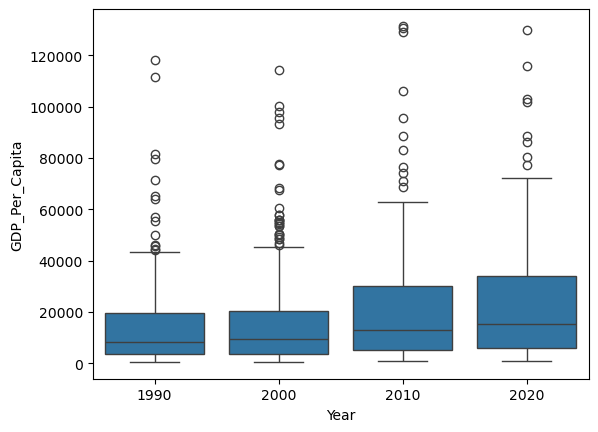

In [25]:
sns.boxplot( x=gdp_decades['Year'], y=gdp_decades['GDP_Per_Capita'] )

([<matplotlib.axis.XTick at 0x28be443fed0>,
 [Text(1990, 0, '1990'),
  Text(2000, 0, '2000'),
  Text(2010, 0, '2010'),
  Text(2020, 0, '2020')])

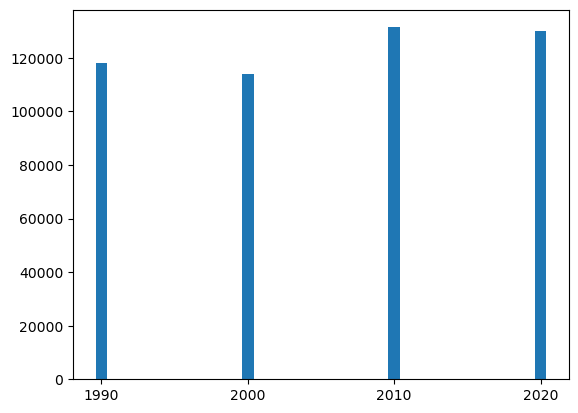

In [26]:
plt.bar(gdp_decades['Year'], gdp_decades['GDP_Per_Capita'])
plt.xticks([1990, 2000, 2010, 2020])

([<matplotlib.axis.XTick at 0x28be5c37d90>,
 [Text(1990, 0, '1990'),
  Text(2000, 0, '2000'),
  Text(2010, 0, '2010'),
  Text(2020, 0, '2020')])

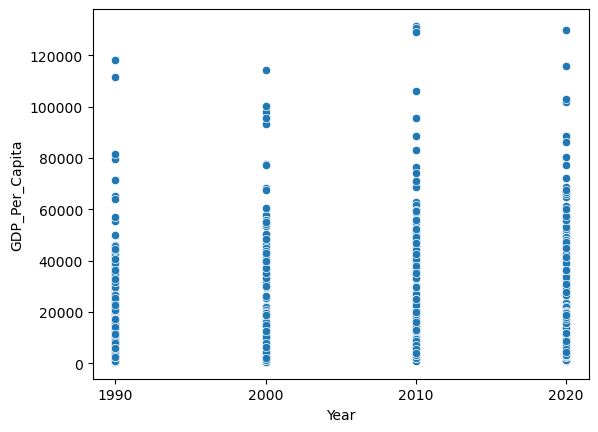

In [27]:
sns.scatterplot(x=gdp_decades['Year'], y=gdp_decades['GDP_Per_Capita'])
plt.xticks([1990, 2000, 2010, 2020])

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

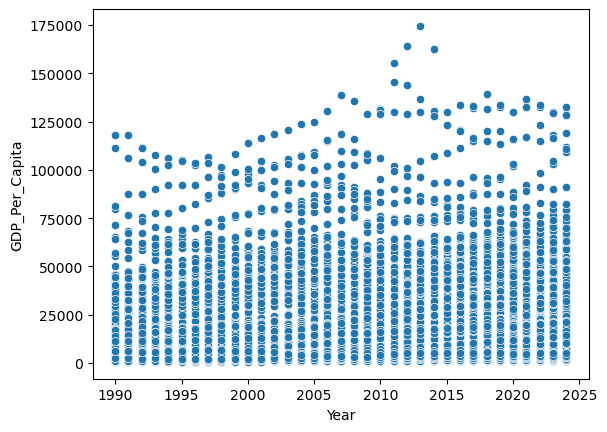

In [28]:
sns.scatterplot(x=gdp_df['Year'], y=gdp_df['GDP_Per_Capita'])

([<matplotlib.axis.XTick at 0x28be5d1ec10>,
 [Text(1990, 0, '1990'),
  Text(2000, 0, '2000'),
  Text(2010, 0, '2010'),
  Text(2020, 0, '2020')])

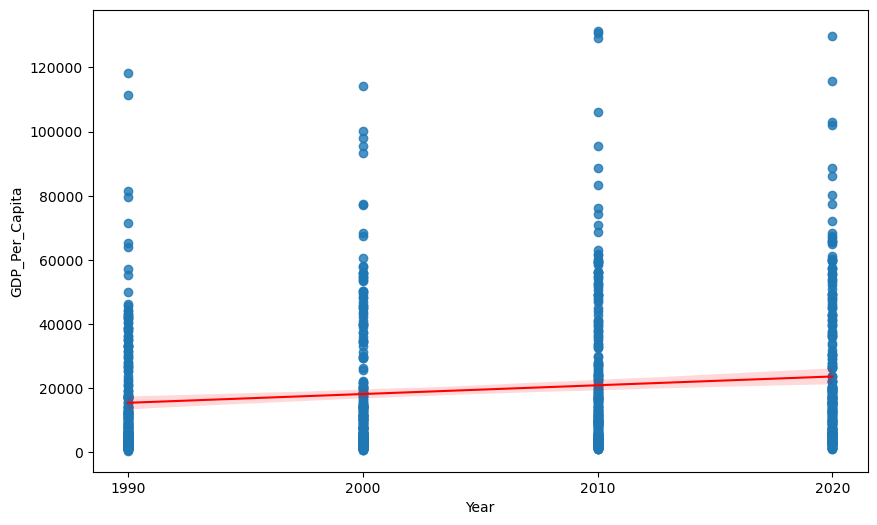

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    x=gdp_decades['Year'],
    y=gdp_decades['GDP_Per_Capita'],
    line_kws={'color': 'red', 'linewidth': 1.5},
    ax=ax
)
plt.xticks([1990, 2000, 2010, 2020])

In [30]:
#10 GDP is on a gradual rise over time, dont really think this is the best plot to show this but maybe Im doing the scatter wrong

In [31]:
gdp_df[gdp_df['GDP_Per_Capita'] > 100000]

,Country,Year,GDP_Per_Capita
794,Bermuda,2024,109311.936941
795,Bermuda,2023,103052.348368
807,Bermuda,2011,101989.927296
808,Bermuda,2010,105968.875104
809,Bermuda,2009,108962.816946
...,...,...,...
8058,United Arab Emirates,1994,102456.104720
8059,United Arab Emirates,1993,100422.631522
8060,United Arab Emirates,1992,104206.754891
8061,United Arab Emirates,1991,106266.193694


In [ ]:
#solution
gdp_df.loc[gdp_df.GDP_Per_Capita > 100000].sort_values('Year')  #.head(2) for top 2
#different way, below is better for rerunning data, not just one time thing
rich_df = gdp_df.loc[gdp_df.GDP_Per_Capita > 100000]
min_year = rich _df.min()
rich_df.loc[rich_df.Year == min_year]

In [32]:
round(gdp_df[gdp_df['GDP_Per_Capita'] > 100000].tail(1), 2)

,Country,Year,GDP_Per_Capita
8062,United Arab Emirates,1990,111377.05


In [33]:
#11 UAE in the year 1990 got above $100,000 GDP

In [34]:
gdp_df[gdp_df['Year'] == 2020]['GDP_Per_Capita'].max()

129865.629988164

In [35]:
gdp_df[gdp_df['GDP_Per_Capita'] == 129865.629988164]['Country']

4629    Luxembourg
Name: Country, dtype: object

In [ ]:
#soluiotn
richest_2020 = gdp_2020.sort_values('GDP_Per_Capita').tail(1)['Country'] #this is a series
gdp_df[gdp_df.Country.isin(richest_2020)]
gpd_df[gdp_df.Country.isin(richest_2020)].plot(x = 'Year', y = 'GDP_Per_Capita');

In [36]:
#12 Luxembourg has the highest GDP in 2020 at $129865.63

In [37]:
gdp_df[gdp_df['Year'] == 2020]['GDP_Per_Capita'].min()

1030.7702641937117

In [38]:
gdp_df[gdp_df['GDP_Per_Capita'] == 1030.7702641937117]['Country']

1112    Burundi
Name: Country, dtype: object

In [ ]:
#solution
poor_2020 = gdp_df.sort_values('GDP_Per_Capita').head(1).Country
gdp_df[gdp_df.Country.isin(poor_2020)].plot(x = 'Year', y = 'GDP_Per_Capita');

In [39]:
#13 Burundi has the lowest GDP in 2020 at $1030.77

In [40]:
gdp_df[gdp_df['Country'] == 'Burundi'].head()

,Country,Year,GDP_Per_Capita
1108,Burundi,2024,1051.259313
1109,Burundi,2023,1036.167122
1110,Burundi,2022,1031.254122
1111,Burundi,2021,1035.538574
1112,Burundi,2020,1030.770264


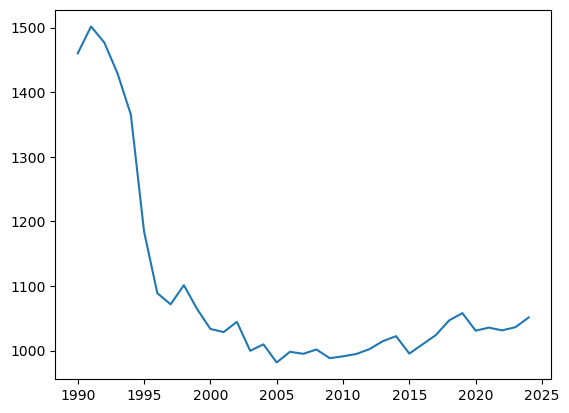

In [41]:
Burundi_gdp = gdp_df[gdp_df['Country'] == 'Burundi']
plt.plot(Burundi_gdp['Year'],Burundi_gdp['GDP_Per_Capita'])

In [ ]:
#solution
gdp_2020
gdp_1990 = gdp_df.loc[gdp_df.Year == 1990]
gdp_merged = pd.merge(gdp_1990, gdp_2020, on = 'Country', how = 'inner')
gdp_merged.loc[gdp_merged.GDP_Per_Capita_y < gdp_merged.GDP_Per_Capita_x].Country #doing .Country will show just the country names, can be used without

In [42]:
# DONT FORGET BONUS QUESTION

In [43]:
#internet_df = pd.read_csv('../data/internet_use.csv')
#internet_df

In [44]:
#internet_df = pd.read_csv('../data/internet_use.csv', 
#                             skipfooter=298,  
#                             sep=',',              
#                             encoding='utf-8')
#internet_df

In [ ]:
#solution
# internet = pd.read_csv('../data/internet_use.csv', nrows = 6083)

In [45]:
internet_df = pd.read_csv('../data/internet_use.csv', 
                         skipfooter=298,  # Number of lines at bottom of file to skip
                         sep=',',   # Character or regex pattern to treat as the delimiter  
                         engine='python',  # Parser engine to use. The C and pyarrow engines are faster, while the python engine is currently more feature-complete
                         on_bad_lines='skip')  # skip bad lines without raising or warning when they are encountered

internet_df

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.600000,1
1,Afghanistan,2018,16.800000,2
2,Afghanistan,2017,13.500000,3
3,Afghanistan,2016,11.000000,4
4,Afghanistan,2015,8.260000,4
...,...,...,...,...
6078,Zimbabwe,1997,0.033080,NaN
6079,Zimbabwe,1996,0.016790,NaN
6080,Zimbabwe,1995,0.007684,NaN
6081,Zimbabwe,1994,0.001739,NaN


In [46]:
internet_df.dtypes

Country or Area     object
Year                 int64
Value              float64
Value Footnotes     object
dtype: object

In [47]:
internet_df = internet_df.drop(columns=['Value Footnotes'])
internet_df.columns = ['Country', 'Year', 'Internet_Users_Pct']
internet_df.head()

,Country,Year,Internet_Users_Pct
0,Afghanistan,2019,17.60
1,Afghanistan,2018,16.80
2,Afghanistan,2017,13.50
3,Afghanistan,2016,11.00
4,Afghanistan,2015,8.26


In [48]:
internet_df['Year'].nunique()

34

In [49]:
internet_df[internet_df['Internet_Users_Pct'] != 0]['Year'].min()

1990

In [50]:
#17 1990 is the first year to have a non-zero value 

In [51]:
internt_2000 = internet_df[internet_df['Year'] == 2000]
internt_2014 = internet_df[internet_df['Year'] == 2014]

<Axes: xlabel='Internet_Users_Pct', ylabel='Density'>

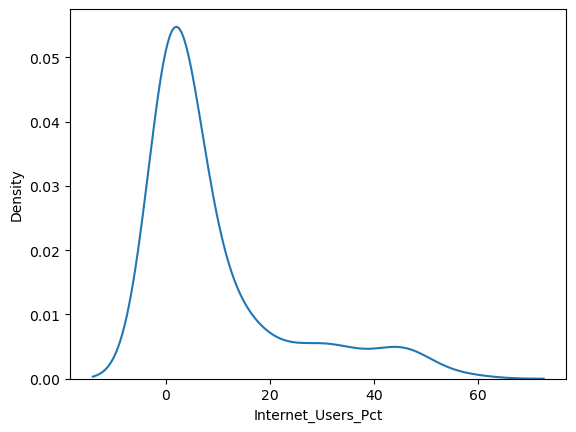

In [52]:
sns.kdeplot(internt_2000['Internet_Users_Pct'])

<Axes: xlabel='Internet_Users_Pct', ylabel='Density'>

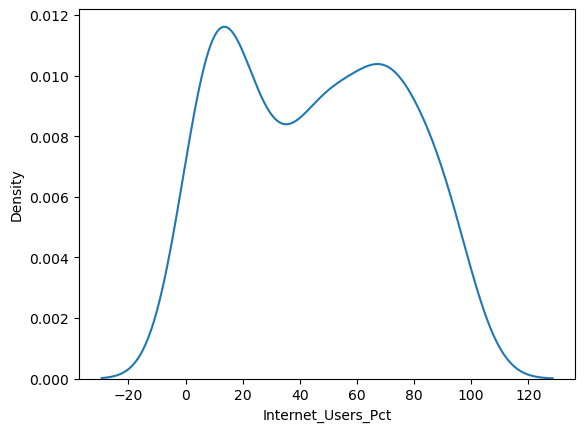

In [53]:
sns.kdeplot(internt_2014['Internet_Users_Pct'])

(array([99., 20., 21., 12.,  6.,  6.,  6.,  3.,  2.,  4.,  1.,  3.,  4.,
         2.,  3.,  3.,  1.,  1.,  4.,  3.,  3.,  1.,  1.,  0.,  1.]),
 array([ 0.      ,  2.344828,  4.689656,  7.034484,  9.379312, 11.72414 ,
        14.068968, 16.413796, 18.758624, 21.103452, 23.44828 , 25.793108,
        28.137936, 30.482764, 32.827592, 35.17242 , 37.517248, 39.862076,
        42.206904, 44.551732, 46.89656 , 49.241388, 51.586216, 53.931044,
        56.275872, 58.6207  ]),
 <BarContainer object of 25 artists>)

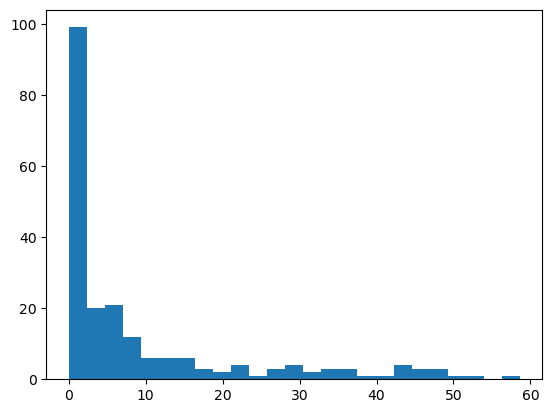

In [54]:
plt.hist(internt_2000['Internet_Users_Pct'], bins=25)

(array([10., 18., 11.,  9., 12.,  8.,  4.,  6.,  6.,  5.,  6.,  8., 10.,
         9.,  6.,  5., 11., 11.,  8.,  8.,  4., 10.,  4.,  8.,  7.]),
 array([ 0.99   ,  4.87672,  8.76344, 12.65016, 16.53688, 20.4236 ,
        24.31032, 28.19704, 32.08376, 35.97048, 39.8572 , 43.74392,
        47.63064, 51.51736, 55.40408, 59.2908 , 63.17752, 67.06424,
        70.95096, 74.83768, 78.7244 , 82.61112, 86.49784, 90.38456,
        94.27128, 98.158  ]),
 <BarContainer object of 25 artists>)

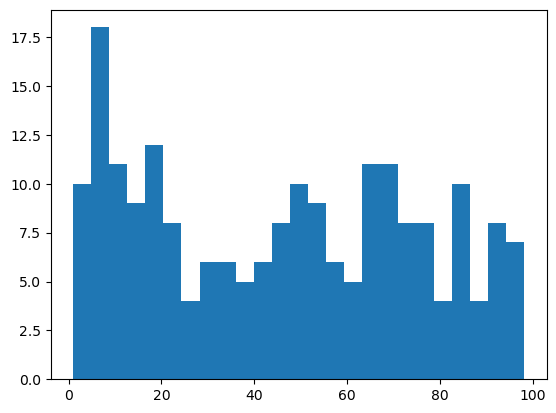

In [55]:
plt.hist(internt_2014['Internet_Users_Pct'], bins=25)

In [56]:
#18 There are many more countries with a greater than 0 internet percentage in 2014

In [57]:
internt_2014[internt_2014['Internet_Users_Pct'] < 5].count()

Country               10
Year                  10
Internet_Users_Pct    10
dtype: int64

In [58]:
#19 10 (ten) countries had less than 5% internet users in 2014

In [59]:
gdp_and_internet_df = pd.merge(
    internet_df,
    gdp_df,
    on=['Country', 'Year'],
    how='inner'
)

In [60]:
gdp_and_internet_df

,Country,Year,Internet_Users_Pct,GDP_Per_Capita
0,Afghanistan,2019,17.600000,2927.245144
1,Afghanistan,2018,16.800000,2902.392113
2,Afghanistan,2017,13.500000,2952.998916
3,Afghanistan,2016,11.000000,2958.785399
4,Afghanistan,2015,8.260000,2967.692067
...,...,...,...,...
4763,Zimbabwe,1997,0.033080,6524.062658
4764,Zimbabwe,1996,0.016790,6474.160183
4765,Zimbabwe,1995,0.007684,5964.589380
4766,Zimbabwe,1994,0.001739,6010.742417


In [61]:
gdp_and_internet_df[gdp_and_internet_df['Year'] == 2014]['Internet_Users_Pct'].nlargest(3)

1990    98.1580
540     96.8000
3238    96.3005
Name: Internet_Users_Pct, dtype: float64

In [62]:
top_internet_2014 = (
    gdp_and_internet_df[gdp_and_internet_df['Year'] == 2014]
    .nlargest(3, 'Internet_Users_Pct')
    [['Country', 'Internet_Users_Pct']]
)
top_internet_2014

,Country,Internet_Users_Pct
1990,Iceland,98.1580
540,Bermuda,96.8000
3238,Norway,96.3005


In [63]:
top_3_df = gdp_and_internet_df[gdp_and_internet_df['Country'].isin(['Iceland', 'Bermuda', 'Norway'])]

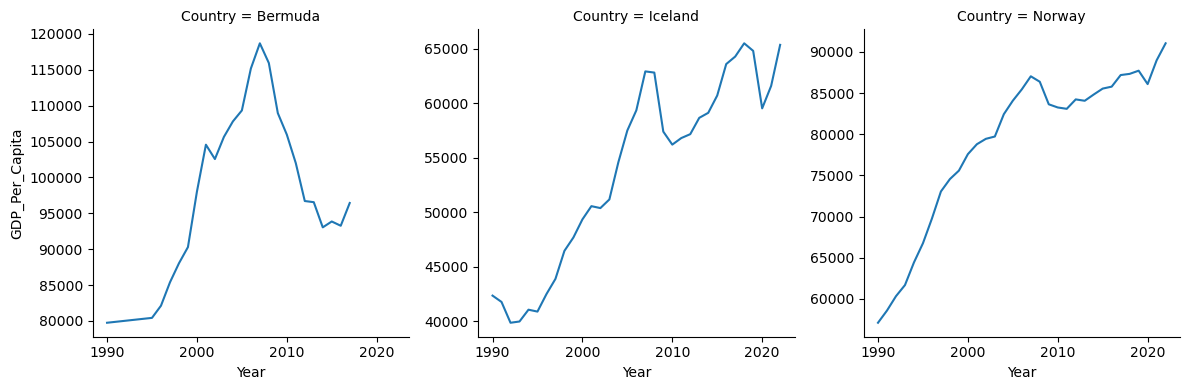

In [64]:
top_3_grid = sns.FacetGrid(
    data=top_3_df,
    col='Country',
    height=4,
    sharey=False
)
top_3_grid.map_dataframe(
    sns.lineplot,
    x='Year',
    y='GDP_Per_Capita'
)
plt.show()

In [65]:
#21 Bermuda's GDP drops pretty drastically after ~2008

In [66]:
iceland_internet = gdp_and_internet_df[gdp_and_internet_df['Country'] == 'Iceland']
iceland_internet.head()

,Country,Year,Internet_Users_Pct,GDP_Per_Capita
1982,Iceland,2022,99.8565,65380.317305
1983,Iceland,2021,99.6870,61610.213274
1984,Iceland,2020,99.5328,59543.813499
1985,Iceland,2019,99.5049,64826.432409
1986,Iceland,2018,99.0110,65521.931342


<Axes: xlabel='Year', ylabel='Internet_Users_Pct'>

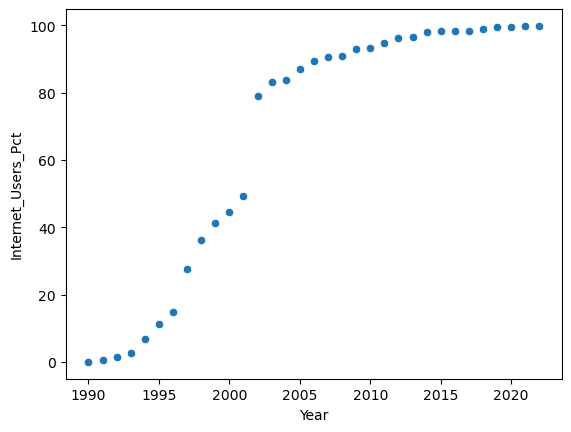

In [67]:
sns.scatterplot(x=iceland_internet['Year'], y=iceland_internet['Internet_Users_Pct'])

In [68]:
bermuda_internet = gdp_and_internet_df[gdp_and_internet_df['Country'] == 'Bermuda']
bermuda_internet.head()

,Country,Year,Internet_Users_Pct,GDP_Per_Capita
537,Bermuda,2017,98.3700,96437.191439
538,Bermuda,2016,98.0000,93265.067536
539,Bermuda,2015,98.3236,93859.876949
540,Bermuda,2014,96.8000,93042.273305
541,Bermuda,2013,95.3000,96549.787481


<Axes: xlabel='Year', ylabel='Internet_Users_Pct'>

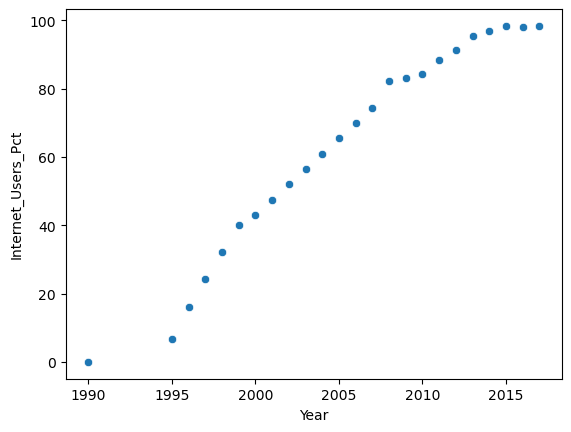

In [69]:
sns.scatterplot(x=bermuda_internet['Year'], y=bermuda_internet['Internet_Users_Pct'])

In [70]:
norway_internet = gdp_and_internet_df[gdp_and_internet_df['Country'] == 'Norway']
norway_internet.head()

,Country,Year,Internet_Users_Pct,GDP_Per_Capita
3230,Norway,2022,99.0000,91051.083197
3231,Norway,2021,99.0000,88984.138674
3232,Norway,2020,94.6076,86096.050895
3233,Norway,2019,98.0000,87725.728325
3234,Norway,2018,96.4917,87338.470801


<Axes: xlabel='Year', ylabel='Internet_Users_Pct'>

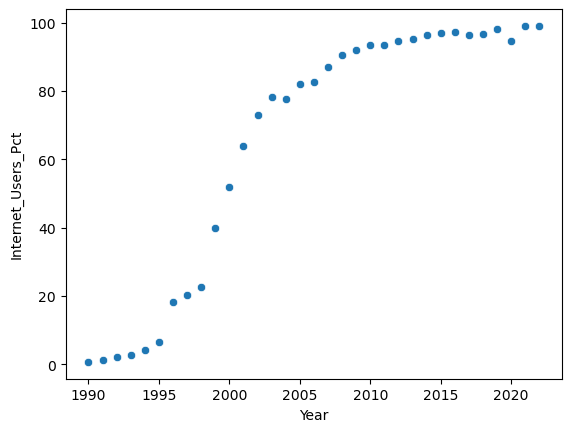

In [71]:
sns.scatterplot(x=norway_internet['Year'], y=norway_internet['Internet_Users_Pct'])

In [72]:
gpd_internet_2014 = gdp_and_internet_df[gdp_and_internet_df['Year'] == 2014]
gpd_internet_2014

,Country,Year,Internet_Users_Pct,GDP_Per_Capita
5,Afghanistan,2014,7.0000,3017.942544
27,Albania,2014,54.3000,12718.284760
56,Algeria,2014,29.5000,15073.762940
85,Andorra,2014,86.1000,59929.244467
112,Angola,2014,21.3623,11721.664416
...,...,...,...,...
4644,Vanuatu,2014,18.8000,3302.291779
4672,Viet Nam,2014,41.0000,8751.882806
4695,Virgin Islands (US),2014,50.0700,42853.898660
4716,Zambia,2014,6.5000,3585.577485


<Axes: xlabel='Internet_Users_Pct', ylabel='GDP_Per_Capita'>

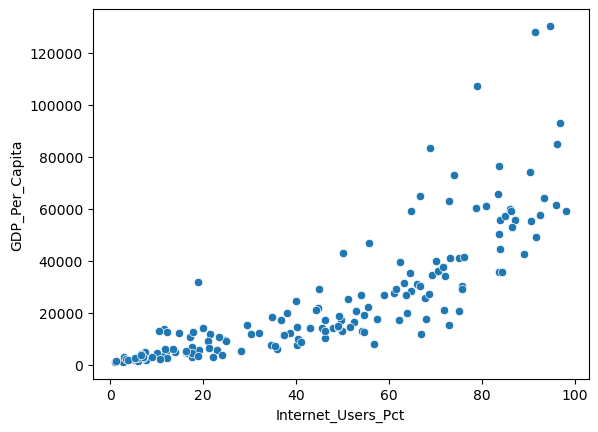

In [73]:
sns.scatterplot(x=gpd_internet_2014['Internet_Users_Pct'], y=gpd_internet_2014['GDP_Per_Capita'])

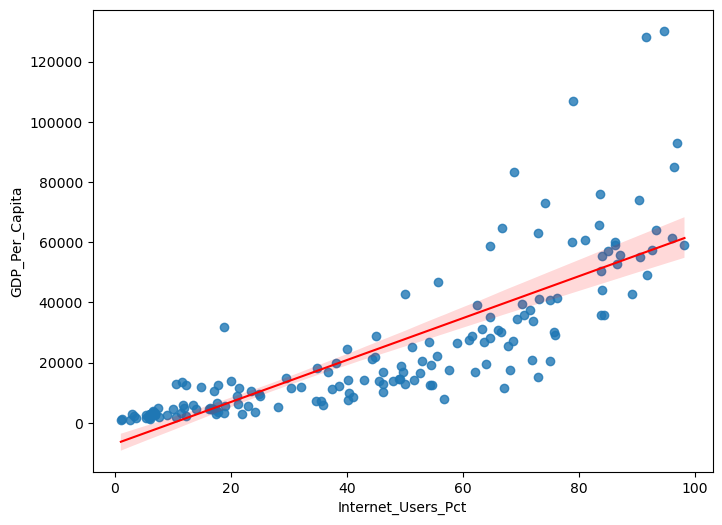

In [74]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    x=gpd_internet_2014['Internet_Users_Pct'],
    y=gpd_internet_2014['GDP_Per_Capita'],
    line_kws={'color': 'red', 'linewidth': 1.5},
    ax=ax
)
plt.show()